In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan5 import *

In [2]:
model = JordanNet(d=5, num_classes=len(block_types))

In [ ]:
matrices, labels, features, dists = generate_training_dataset(
    matrices_per_class=20_000,
    d=5,
    mode="random",
    lam=1,
    device=device,
)

In [3]:
print(dists.mean(dim=0))
print(dists.std(dim=0))
print(dists.max(), dists.min())

tensor([0.1299, 0.1491, 0.1530, 0.1539, 0.1310, 0.1437, 0.1395],
       device='privateuseone:0')
tensor([0.1770, 0.1438, 0.1290, 0.1245, 0.2254, 0.1494, 0.3235],
       device='privateuseone:0')
tensor(0.9314, device='privateuseone:0') tensor(0.0003, device='privateuseone:0')


C:\Users\micha\AppData\Local\Temp\ipykernel_21576\668713694.py:2: UserWarning: The operator 'aten::std.correction' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  print(dists.std(dim=0))


In [4]:
model = train_jordan_net(
    model,
    features,
    dists,
    num_epochs=20,
    device=device,
)

Epoch [1/20] | Train Loss: 0.020853 | Val Loss: 0.004341
Epoch [2/20] | Train Loss: 0.003894 | Val Loss: 0.002559
Epoch [3/20] | Train Loss: 0.003678 | Val Loss: 0.002051
Epoch [4/20] | Train Loss: 0.002102 | Val Loss: 0.003799
Epoch [5/20] | Train Loss: 0.001802 | Val Loss: 0.001981
Epoch [6/20] | Train Loss: 0.001619 | Val Loss: 0.001678
Epoch [7/20] | Train Loss: 0.001686 | Val Loss: 0.001664
Epoch [8/20] | Train Loss: 0.001641 | Val Loss: 0.002301
Epoch [9/20] | Train Loss: 0.001816 | Val Loss: 0.001578
Epoch [10/20] | Train Loss: 0.001216 | Val Loss: 0.001020
Epoch [11/20] | Train Loss: 0.001377 | Val Loss: 0.001414
Epoch [12/20] | Train Loss: 0.001067 | Val Loss: 0.001332
Epoch [13/20] | Train Loss: 0.002667 | Val Loss: 0.001384
Early stopping triggered at epoch 13. Best Val Loss: 0.001020


c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan5.py:352: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sandbox/model_jordan6.pth"

In [3]:
model.load_state_dict(torch.load("sandbox/model_jordan6.pth"))

C:\Users\micha\AppData\Local\Temp\ipykernel_3364\31064178.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sandbox/model_jordan6.pth"))


<All keys matched successfully>

C:\Users\micha\AppData\Local\Temp\ipykernel_20608\1660763661.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  X_batch = torch.tensor(Xs, dtype=torch.float32)
c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: The operator 'aten::_transformer_encoder_layer_fwd' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._transformer_encoder_layer_fwd(


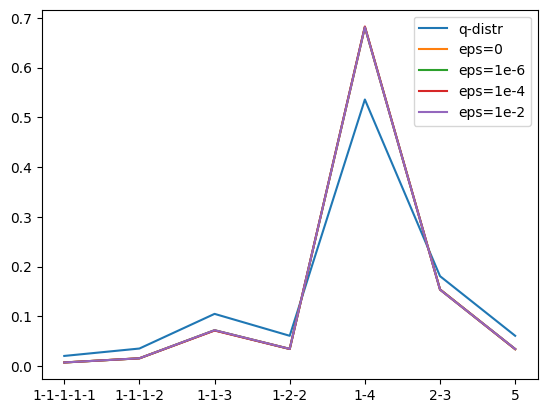

In [4]:
block_type = "1-4"

Xs = [generate_matrix(5, block_type, mode="random", eps=eps, lam=1) for eps in [0, 1e-6, 1e-4, 1e-2]]
X_batch = torch.tensor(Xs, dtype=torch.float32)
X_features = torch.tensor([per_power_features(X, lam=1) for X in Xs], dtype=torch.float32)

model.eval()
logits = model(X_features.to(device))
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

plt.plot(q_batch([block_type], eps=1e-4).detach().cpu().numpy()[0], label="q-distr")

for prob, label in zip(probs, ["eps=0", "eps=1e-6", "eps=1e-4", "eps=1e-2", "eps=1"]):
    plt.plot(prob, label=label)
plt.legend()
plt.xticks(ticks=range(len(block_types)), labels=block_types)
plt.show()

In [19]:
q_batch([block_type], eps=1e-4).detach().cpu().numpy()

array([[0.02062322, 0.03549122, 0.10511151, 0.06107812, 0.5357276 ,
        0.18089011, 0.06107812]], dtype=float32)

In [4]:
def test_jordan_net(model, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    matrices_test, labels_test, features_test, dists_test = generate_training_dataset(
        matrices_per_class=matrices_per_class,
        d=5,
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        lam=1,
        device="cpu",
    )

    loader = DataLoader(TensorDataset(features_test, labels_test, dists_test), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels_test.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(batch_features)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    cm = confusion_matrix(true_classes, predicted_classes)

    return cm, kl_avg



c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: The operator 'aten::_transformer_encoder_layer_fwd' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._transformer_encoder_layer_fwd(


eps=0:
	Accuracy 0.9727,
	KL loss 0.646664 


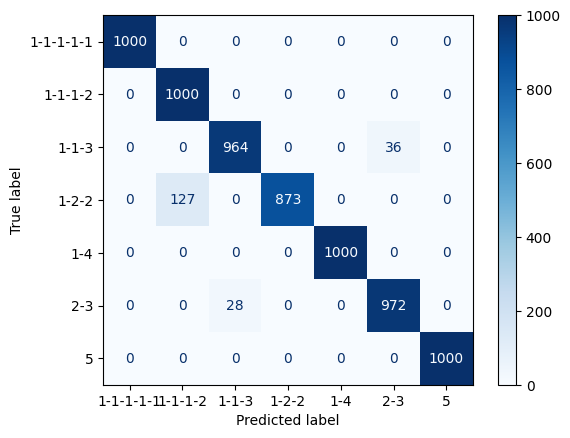

eps=1e-06:
	Accuracy 0.9959,
	KL loss 0.001400 


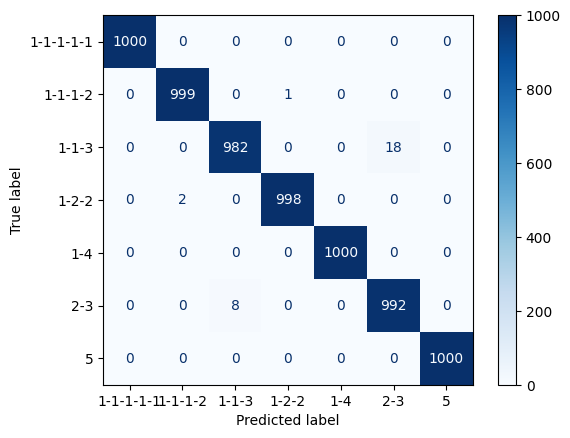

eps=0.0001:
	Accuracy 0.9537,
	KL loss 0.049508 


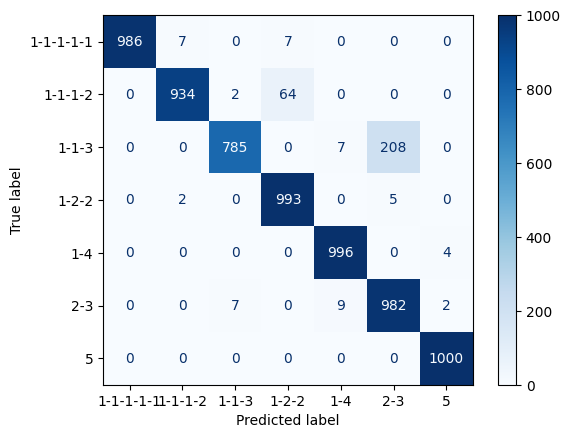

eps=0.01:
	Accuracy 0.3493,
	KL loss 0.777423 


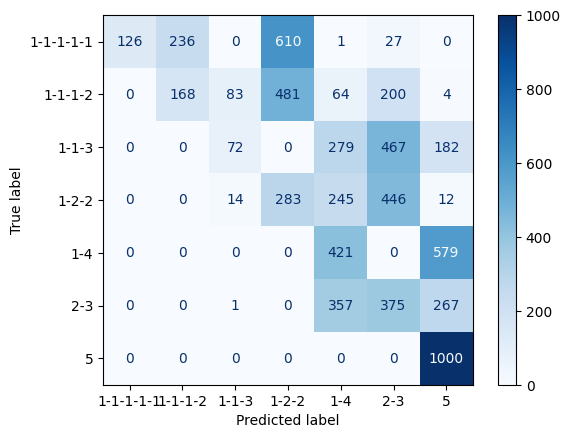

eps=0.1:
	Accuracy 0.1430,
	KL loss 2.591112 


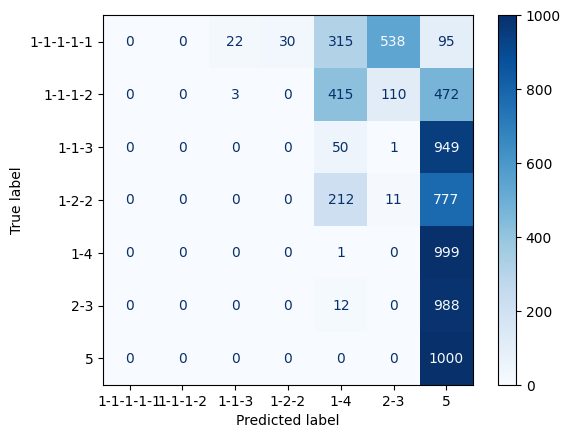

eps=1.0:
	Accuracy 0.1429,
	KL loss 3.246767 


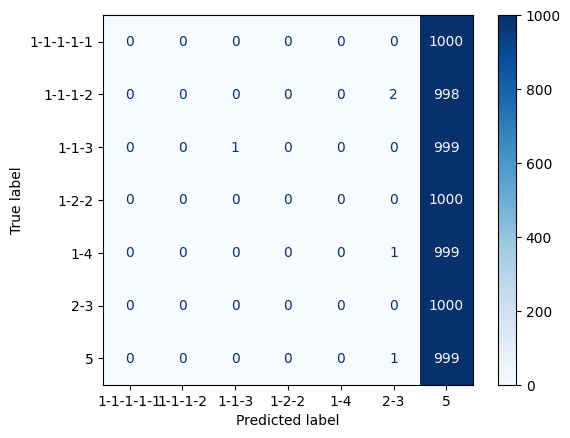

ortho:
	Accuracy 0.9971,
	KL loss 0.630188 


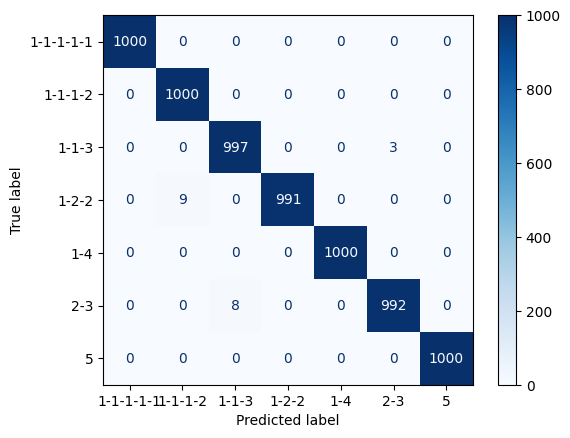

In [5]:
cms = {}
kls = {}

model.cpu()

for eps in [0, 1e-6, 1e-4, 1e-2, 0.1, 1.]:
    cm, kl_div = test_jordan_net(model, mode="random", eps=eps, eps_range=None)
    cms[f"eps={eps}"] = cm
    kls[f"eps={eps}"] = kl_div

cm, kl_div = test_jordan_net(model, mode="ortho", eps=0., eps_range=None)
cms["ortho"] = cm
kls["ortho"] = kl_div

accuracies = {}
for eps, cm in cms.items():
    accuracy = np.trace(cm) / np.sum(cm)
    accuracies[eps] = accuracy

for k in accuracies.keys():
    print(f"{k}:\n\tAccuracy {accuracies[k]:.4f},\n\tKL loss {kls[k]:.6f} ")
    ConfusionMatrixDisplay(confusion_matrix=cms[k], display_labels=block_types).plot(cmap=plt.cm.Blues)
    plt.show()